In [2]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# Multi-Layer Architecture (MLA) with Backpropagation

A fully connected neural network built from scratch using PyTorch tensors.  
Architecture: **Input → Hidden Layer 1 → Hidden Layer 2 → Output**

## Step 1: Define the MLA (Multi-Layer Architecture)

In [8]:
class MLA(nn.Module):
    """
    Multi-Layer Architecture (MLA) Neural Network
    
    Layers:
      - Input:    input_size  neurons
      - Hidden 1: hidden1_size neurons  + ReLU
      - Hidden 2: hidden2_size neurons  + ReLU
      - Output:   output_size neurons   (linear, for regression / raw logits)
    """
    def __init__(self, input_size, hidden1_size, hidden2_size, output_size):
        super(MLA, self).__init__()
        self.layer1 = nn.Linear(input_size, hidden1_size)
        self.layer2 = nn.Linear(hidden1_size, hidden2_size)
        self.layer3 = nn.Linear(hidden2_size, output_size)
        self.relu   = nn.ReLU()

    def forward(self, x):
        # Forward pass through each layer
        x = self.relu(self.layer1(x))   # Input  → Hidden 1
        x = self.relu(self.layer2(x))   # Hidden 1 → Hidden 2
        x = self.layer3(x)              # Hidden 2 → Output
        return x

# Instantiate the model
input_size   = 2
hidden1_size = 4
hidden2_size = 4
output_size  = 1

model = MLA(input_size, hidden1_size, hidden2_size, output_size)
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters())}")

MLA(
  (layer1): Linear(in_features=2, out_features=4, bias=True)
  (layer2): Linear(in_features=4, out_features=4, bias=True)
  (layer3): Linear(in_features=4, out_features=1, bias=True)
  (relu): ReLU()
)

Total parameters: 37


## Step 2: Create Dataset (XOR Problem)

In [9]:
# XOR dataset: a classic non-linearly separable problem
# A single-layer network cannot solve this — MLA can!
X = torch.tensor([
    [0.0, 0.0],
    [0.0, 1.0],
    [1.0, 0.0],
    [1.0, 1.0],
], dtype=torch.float32)

y = torch.tensor([
    [0.0],  # 0 XOR 0 = 0
    [1.0],  # 0 XOR 1 = 1
    [1.0],  # 1 XOR 0 = 1
    [0.0],  # 1 XOR 1 = 0
], dtype=torch.float32)

print("Input X:\n", X)
print("\nTarget y:\n", y)

Input X:
 tensor([[0., 0.],
        [0., 1.],
        [1., 0.],
        [1., 1.]])

Target y:
 tensor([[0.],
        [1.],
        [1.],
        [0.]])


## Step 3: Training Loop with Backpropagation

In [10]:
loss_fn   = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

epochs = 5000
losses = []

for epoch in range(epochs):
    # ── Forward pass ──────────────────────────────────────────
    y_pred = model(X)
    loss   = loss_fn(y_pred, y)

    # ── Backpropagation ───────────────────────────────────────
    optimizer.zero_grad()   # clear old gradients
    loss.backward()         # compute gradients via chain rule
    optimizer.step()        # update weights: w = w - lr * grad

    losses.append(loss.item())

    if (epoch + 1) % 500 == 0:
        print(f"Epoch [{epoch+1:>5}/{epochs}]  Loss: {loss.item():.6f}")

print("\nTraining complete!")

Epoch [  500/5000]  Loss: 0.000000
Epoch [ 1000/5000]  Loss: 0.000000
Epoch [ 1500/5000]  Loss: 0.000000
Epoch [ 2000/5000]  Loss: 0.000000
Epoch [ 2500/5000]  Loss: 0.000000
Epoch [ 3000/5000]  Loss: 0.000000
Epoch [ 3500/5000]  Loss: 0.000000
Epoch [ 4000/5000]  Loss: 0.000000
Epoch [ 4500/5000]  Loss: 0.000000
Epoch [ 5000/5000]  Loss: 0.000000

Training complete!


## Step 4: Evaluate & Visualize

Input    | Target | Raw Output | Predicted
---------------------------------------------
[0.0, 0.0]  |  0     |  0.0000     |  0
[0.0, 1.0]  |  1     |  1.0000     |  1
[1.0, 0.0]  |  1     |  1.0000     |  1
[1.0, 1.0]  |  0     |  0.0000     |  0


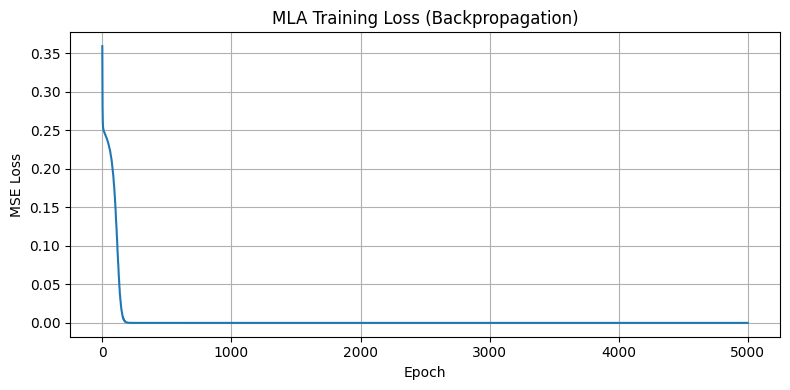

In [11]:
with torch.no_grad():
    predictions = model(X)
    rounded     = predictions.round()

print("Input    | Target | Raw Output | Predicted")
print("-" * 45)
for i in range(len(X)):
    print(f"{X[i].tolist()}  |  {int(y[i].item())}     |  {predictions[i].item():.4f}     |  {int(rounded[i].item())}")

# ── Loss curve ────────────────────────────────────────────────
plt.figure(figsize=(8, 4))
plt.plot(losses)
plt.title("MLA Training Loss (Backpropagation)")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True)
plt.tight_layout()
plt.show()